## H1B LCA Disclosure Data — EDA

Dataset: DOL LCA Disclosure Data, FY2026 Q2 (H-1B / H-1B1 / E-3 visa applications)  

Source: dol.gov/agencies/eta/foreign-labor/performance  
https://www.dol.gov/sites/dolgov/files/ETA/oflc/pdfs/LCA_Record_Layout_FY2026_Q2.pdf

Original data: LCA_Dislclosure_Data_FY2026_Q2.xlsx

Background info: 

An approved Labor Condition Application (LCA) is a required step after an H-1B applicant is selected in the annual H-1B lottery (for cap-subject cases) and before the employer files the official H-1B petition (Form I-129) with USCIS.

Although an LCA is not the final H-1B petition or visa approval, it is a mandatory step in the sponsorship process. Therefore, LCA disclosure data provide valuable insight into which employers are actively sponsoring international talent, which occupations they recruit for, where those jobs are located, and the wages they are willing to offer.

Goal: Understand sponsorship patterns (employer, occupation, wage, geography, approval status) to lay the foundation for later ML + GenAI recommendation work.


### 1. Data Profiling

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('/Users/hyk/Desktop/project/LCA_Dislclosure_Data_FY2026_Q2.xlsx')
print(df.shape)


(210387, 98)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210387 entries, 0 to 210386
Data columns (total 98 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   CASE_NUMBER                     210387 non-null  object        
 1   CASE_STATUS                     210387 non-null  object        
 2   RECEIVED_DATE                   210387 non-null  datetime64[ns]
 3   DECISION_DATE                   208171 non-null  datetime64[ns]
 4   ORIGINAL_CERT_DATE              15952 non-null   datetime64[ns]
 5   VISA_CLASS                      210387 non-null  object        
 6   JOB_TITLE                       210387 non-null  object        
 7   SOC_CODE                        210387 non-null  object        
 8   SOC_TITLE                       210387 non-null  object        
 9   FULL_TIME_POSITION              210387 non-null  object        
 10  BEGIN_DATE                      210387 non-null  datetim

In [7]:
pd.set_option('display.max_columns', None)
df.head(10)

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,ORIGINAL_CERT_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,BEGIN_DATE,END_DATE,TOTAL_WORKER_POSITIONS,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_PREVIOUS_EMPLOYMENT,NEW_CONCURRENT_EMPLOYMENT,CHANGE_EMPLOYER,AMENDED_PETITION,EMPLOYER_NAME,TRADE_NAME_DBA,EMPLOYER_ADDRESS1,EMPLOYER_ADDRESS2,EMPLOYER_CITY,EMPLOYER_STATE,EMPLOYER_POSTAL_CODE,EMPLOYER_COUNTRY,EMPLOYER_PROVINCE,EMPLOYER_PHONE,EMPLOYER_PHONE_EXT,EMPLOYER_FEIN,NAICS_CODE,EMPLOYER_POC_LAST_NAME,EMPLOYER_POC_FIRST_NAME,EMPLOYER_POC_MIDDLE_NAME,EMPLOYER_POC_JOB_TITLE,EMPLOYER_POC_ADDRESS1,EMPLOYER_POC_ADDRESS2,EMPLOYER_POC_CITY,EMPLOYER_POC_STATE,EMPLOYER_POC_POSTAL_CODE,EMPLOYER_POC_COUNTRY,EMPLOYER_POC_PROVINCE,EMPLOYER_POC_PHONE,EMPLOYER_POC_PHONE_EXT,EMPLOYER_POC_EMAIL,AGENT_REPRESENTING_EMPLOYER,AGENT_ATTORNEY_LAST_NAME,AGENT_ATTORNEY_FIRST_NAME,AGENT_ATTORNEY_MIDDLE_NAME,AGENT_ATTORNEY_ADDRESS1,AGENT_ATTORNEY_ADDRESS2,AGENT_ATTORNEY_CITY,AGENT_ATTORNEY_STATE,AGENT_ATTORNEY_POSTAL_CODE,AGENT_ATTORNEY_COUNTRY,AGENT_ATTORNEY_PROVINCE,AGENT_ATTORNEY_PHONE,AGENT_ATTORNEY_PHONE_EXT,AGENT_ATTORNEY_EMAIL_ADDRESS,LAWFIRM_NAME_BUSINESS_NAME,LAWFIRM_BUSINESS_FEIN,STATE_OF_HIGHEST_COURT,NAME_OF_HIGHEST_STATE_COURT,WORKSITE_WORKERS,SECONDARY_ENTITY,SECONDARY_ENTITY_BUSINESS_NAME,WORKSITE_ADDRESS1,WORKSITE_ADDRESS2,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_TRACKING_NUMBER,PW_WAGE_LEVEL,PW_OES_YEAR,PW_OTHER_SOURCE,PW_OTHER_YEAR,PW_SURVEY_PUBLISHER,PW_SURVEY_NAME,TOTAL_WORKSITE_LOCATIONS,AGREE_TO_LC_STATEMENT,H_1B_DEPENDENT,WILLFUL_VIOLATOR,SUPPORT_H1B,STATUTORY_BASIS,APPENDIX_A_ATTACHED,PUBLIC_DISCLOSURE,PREPARER_LAST_NAME,PREPARER_FIRST_NAME,PREPARER_MIDDLE_INITIAL,PREPARER_BUSINESS_NAME,PREPARER_EMAIL
0,I-200-26083-726723,Certified - Withdrawn,2026-03-24,2026-03-31,2026-03-31,H-1B,Specialist - Software Engineering,15-1252.00,Software Developers,Y,2026-03-26,2029-03-25,1,0,0,0,0,1,0,LTIMindtree Limited,NaN,2035 Lincoln Highway,Suite 3004,Edison,NJ,08817,UNITED STATES OF AMERICA,NaN,17322486150,NaN,22-3524303,541511,Sukhtankar,Minal,NaN,Specialist-Immigration Services,2035 Lincoln Highway,STE 3004,Edison,NJ,08817,UNITED STATES OF AMERICA,NaN,17323315746,NaN,minal.sukhtankar@ltm.com,Yes,Coughlin,Brian,J.,200 State Street,13th Floor,Boston,MA,02109,UNITED STATES OF AMERICA,NaN,1.617722e+10,NaN,BOS-Immigration-NIV@fisherphillips.com,Fisher & Phillips LLP,58-0619559,MA,Massachusetts Supreme Judicial Court,1,Yes,Citibank,388 Greenwich St,NaN,New York,NaN,NY,10013,139000.00,NaN,Year,131997.00,Year,NaN,II,7/1/2025 - 6/30/2026,NaN,NaN,NaN,NaN,2,Yes,Yes,No,Yes,"$60,000 or higher annual wage",NaN,Disclose Business,Gaughan,Brendan,NaN,Fisher & Phillips LLP,bgaughan@fisherphillips.com
1,I-200-26083-725968,Certified - Withdrawn,2026-03-24,2026-03-31,2026-03-31,H-1B,Director of Business Development,11-2021.00,Marketing Managers,Y,2026-03-30,2029-03-29,1,0,0,0,0,0,1,"Structural Group, Inc.",NaN,10150 Old Columbia Road,NaN,Columbia,MD,21046,UNITED STATES OF AMERICA,NaN,14102152539,NaN,52-1071818,236210,Goldbeck,Tamarah,NaN,Human Resources Operations Manager,10150 Old Columbia Road,NaN,Columbia,MD,21046,UNITED STATES OF AMERICA,NaN,14102152539,NaN,tgoldbeck@structuralgroup.com,Yes,Broulidakis,Julia,Kathryn Eyman,1 Monument Square,Suite 201,Portland,ME,04101,UNITED STATES OF AMERICA,NaN,1.207478e+10,NaN,jbroulidakis@fisherphillips.com,Fisher & Phillips LLP,58-0619559,ME,Supreme Judicial Court,1,No,NaN,10150 Old Columbia Rd,NaN,Columbia,NaN,MD,21046,215000.00,NaN,Year,193523.00,Year,NaN,IV,7/1/2025 - 6/30/2026,NaN,NaN,NaN,NaN,2,Yes,No,No,NaN,NaN,NaN,Disclose Business,NaN,NaN,NaN,NaN,NaN
2,I-200-26083-725357,Certified - Withdrawn,2026-03-24,2026-03-31,2026-03-31,H-1B,Senior Software Developer,15-1252.00,Software Developers,Y,2026-07-06,2029-07-05,1,0,1,0,0,0,0,"Leidos, Inc.",NaN,1750 Presidents Street,NaN,Reston,VA

210k rows
98 columns (keep 29) 

In [8]:
cols_to_keep = ['CASE_NUMBER','CASE_STATUS','RECEIVED_DATE','DECISION_DATE',
                 'VISA_CLASS','JOB_TITLE','SOC_CODE','SOC_TITLE','FULL_TIME_POSITION',
                 'NEW_EMPLOYMENT','CONTINUED_EMPLOYMENT','CHANGE_EMPLOYER',
                 'TOTAL_WORKER_POSITIONS',
                 'EMPLOYER_NAME','EMPLOYER_CITY','EMPLOYER_STATE','NAICS_CODE',
                 'WAGE_RATE_OF_PAY_FROM','WAGE_RATE_OF_PAY_TO','WAGE_UNIT_OF_PAY',
                 'PREVAILING_WAGE','PW_UNIT_OF_PAY','PW_WAGE_LEVEL',
                 'WORKSITE_CITY','WORKSITE_STATE','TOTAL_WORKSITE_LOCATIONS',
                 'AGENT_REPRESENTING_EMPLOYER',
                 'H_1B_DEPENDENT','WILLFUL_VIOLATOR']

df = df[cols_to_keep]
print(df.shape)

(210387, 29)


In [9]:
pd.set_option('display.max_columns', None)
df.head(10)

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_EMPLOYER,TOTAL_WORKER_POSITIONS,EMPLOYER_NAME,EMPLOYER_CITY,EMPLOYER_STATE,NAICS_CODE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_WAGE_LEVEL,WORKSITE_CITY,WORKSITE_STATE,TOTAL_WORKSITE_LOCATIONS,AGENT_REPRESENTING_EMPLOYER,H_1B_DEPENDENT,WILLFUL_VIOLATOR
0,I-200-26083-726723,Certified - Withdrawn,2026-03-24,2026-03-31,H-1B,Specialist - Software Engineering,15-1252.00,Software Developers,Y,0,0,1,1,LTIMindtree Limited,Edison,NJ,541511,139000.00,NaN,Year,131997.00,Year,II,New York,NY,2,Yes,Yes,No
1,I-200-26083-725968,Certified - Withdrawn,2026-03-24,2026-03-31,H-1B,Director of Business Development,11-2021.00,Marketing Managers,Y,0,0,0,1,"Structural Group, Inc.",Columbia,MD,236210,215000.00,NaN,Year,193523.00,Year,IV,Columbia,MD,2,Yes,No,No
2,I-200-26083-725357,Certified - Withdrawn,2026-03-24,2026-03-31,H-1B,Senior Software Developer,15-1252.00,Software Developers,Y,0,1,0,1,"Leidos, Inc.",Reston,VA,54199,163000.00,168000.00,Year,148422.00,Year,NaN,Windsor Mill,MD,2,Yes,No,No
3,I-200-26083-726538,Certified - Withdrawn,2026-03-24,2026-03-31,H-1B,Chief Operating Officer,11-1021.00,General and Operations Managers,Y,0,1,0,1,"George S. Hall, Inc.",Parsippany,NJ,541330,334750.00,NaN,Year,241238.00,Year,IV,Parsippany,NJ,1,Yes,No,No
4,I-200-26083-725379,Certified - Withdrawn,2026-03-24,2026-03-31,H-1B,Software Developer,15-1252.00,Software Developers,Y,0,0,0,1,RELIABLE SOFTWARE RESOURCES,NORTHVILLE,MI,54151,99600.00,99600.10,Year,99549.00,Year,II,Albany,NY,1,No,Yes,No
5,I-200-26079-718259,Certified - Withdrawn,2026-03-20,2026-03-31,H-1B,Job Captain,17-1011.00,"Architects, Except Landscape and Naval",Y,0,1,0,1,MBH Architects Inc.,Alameda,CA,541310,94000.00,109000.00,Year,88080.00,Year,NaN,Alameda,CA,2,Yes,No,No
6,I-200-26079-719681,Certified - Withdrawn,2026-03-20,2026-03-31,H-1B,PLM Engineer,17-2141.00,Mechanical Engineers,Y,1,0,0,1,LILLI TECHNOLOGY LLC,PLANO,TX,541512,45.02,49.13,Hour,45.02,Hour,II,Dearborn,MI,1,Yes,Yes,No
7,I-200-26079-719998,Certified - Withdrawn,2026-03-20,2026-03-31,H-1B,Expert Solution Architect,15-1241.00,Computer Network Architects,Y,0,1,0,1,Acxiom LLC,Conway,AR,518210,195000.00,205000.00,Year,154856.00,Year,IV,Frisco,TX,1,Yes,No,No
8,I-200-26078-716862,Certified - Withdrawn,2026-03-19,2026-03-31,H-1B,Job Captain,17-1011.00,"Architects, Except Landscape and Naval",Y,0,1,0,1,MBH Architects Inc.,Alameda,CA,541310,93995.20,109000.00,Year,88080.00,Year,NaN,Alameda,CA,2,Yes,No,No
9,I-200-26078-714983,Certified - Withdrawn,2026-03-19,2026-03-31,H-1B,Data Analyst D,15-2051.00,Data Scientists,Y,0,0,0,1,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,PHILADELPHIA,PA,611310,92258.36,NaN,Year,68578.00,Year,II,Philadelphia,PA,2,No,No,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210387 entries, 0 to 210386
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   CASE_NUMBER                  210387 non-null  object        
 1   CASE_STATUS                  210387 non-null  object        
 2   RECEIVED_DATE                210387 non-null  datetime64[ns]
 3   DECISION_DATE                208171 non-null  datetime64[ns]
 4   VISA_CLASS                   210387 non-null  object        
 5   JOB_TITLE                    210387 non-null  object        
 6   SOC_CODE                     210387 non-null  object        
 7   SOC_TITLE                    210387 non-null  object        
 8   FULL_TIME_POSITION           210387 non-null  object        
 9   NEW_EMPLOYMENT               210387 non-null  int64         
 10  CONTINUED_EMPLOYMENT         210387 non-null  int64         
 11  CHANGE_EMPLOYER           

In [11]:
print('Full row duplicates:', df.duplicated().sum())
print('Duplicate CASE_NUMBER (should be 0, it is the primary key):', df['CASE_NUMBER'].duplicated().sum())

Full row duplicates: 0
Duplicate CASE_NUMBER (should be 0, it is the primary key): 0


In [12]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean()*100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct
WAGE_RATE_OF_PAY_TO,141606,67.31
PW_WAGE_LEVEL,22899,10.88
H_1B_DEPENDENT,6836,3.25
WILLFUL_VIOLATOR,6838,3.25
DECISION_DATE,2216,1.05
EMPLOYER_STATE,41,0.02


### 2 Data Cleaning

#### RECEIVED_DATE & DECISION_DATE

* FY2026 Q1+Q2, cumulative data *

FY 2026: From 10/01/2025 to 09/30/2026

FY 2026 Q1 = October 1, 2025 – December 31, 2025

FY 2026 Q2 = January 1, 2026 – March 31, 2026

DECISION_DATE range observed: 2025-10-01 ~ 2026-03-31
→ This exactly matches FY2026 Q1+Q2 combined, confirming this file is 
  **cumulative year-to-date**, not a single quarter.

This is confirmed by the official DOL record layout document:
"Reporting Period: October 1, 2025 through March 31, 2026...where the date of the determination was issued during the reporting period above."

Note: RECEIVED_DATE extends back to 2021, reflecting a small number of older applications that took longer to reach a final decision. The vast majority of cases were received in 2025–2026.

**Conclusion:** time frame = October 1, 2025 – March 31, 2026 (FY2026 Q1+Q2, 
cumulative data). Data volume is sufficient for this stage of analysis.

In [13]:
print(df['RECEIVED_DATE'].dtype, df['DECISION_DATE'].dtype)
print()
print('RECEIVED_DATE range:', df['RECEIVED_DATE'].min(), '~', df['RECEIVED_DATE'].max())
print('DECISION_DATE range:', df['DECISION_DATE'].min(), '~', df['DECISION_DATE'].max())

datetime64[ns] datetime64[ns]

RECEIVED_DATE range: 2021-01-04 00:00:00 ~ 2026-03-31 00:00:00
DECISION_DATE range: 2025-10-01 00:00:00 ~ 2026-03-31 00:00:00


In [14]:
print('RECEIVED_DATE by year:')
print(df['RECEIVED_DATE'].dt.year.value_counts().sort_index())

RECEIVED_DATE by year:
RECEIVED_DATE
2021        61
2022       422
2023      2894
2024      4148
2025     90097
2026    112765
Name: count, dtype: int64


#### VISA_CLASS data cleaning

remove H-1B1 & E-3

It is important to note that this dataset does not contain only lottery-selected H-1B cases. The LCA disclosure data actually include:
    Cap-subject H-1B applications (subject to the annual H-1B lottery)
    Cap-exempt H-1B applications (e.g., universities and nonprofit research institutions)
    H-1B extensions (continuing employment)
    H-1B amendments (changes to job duties, location, or employment conditions)
    H-1B transfers (changing employers)
    H-1B1 applications (for citizens of Chile and Singapore) # remove needed
    E-3 applications (for Australian citizens) # remove needed

Thus, the H-1B1 and E-3 data will need to be deleted.

In [15]:
df['VISA_CLASS'].unique()

array(['H-1B', 'E-3 Australian', 'H-1B1 Chile', 'H-1B1 Singapore'],
      dtype=object)

In [16]:
df['VISA_CLASS'].value_counts()

VISA_CLASS
H-1B               203416
E-3 Australian       5122
H-1B1 Chile          1027
H-1B1 Singapore       822
Name: count, dtype: int64

In [17]:
print('Before filtering:', df.shape)
df = df[df['VISA_CLASS'] == 'H-1B'].copy()
print('After filtering to H-1B only:', df.shape)

Before filtering: (210387, 29)
After filtering to H-1B only: (203416, 29)


In [18]:
df['VISA_CLASS'].value_counts()

VISA_CLASS
H-1B    203416
Name: count, dtype: int64

#### WAGE data cleaning

Use `WAGE_RATE_OF_PAY_FROM` as the primary wage field for analysis, since it has 0% missing values across all records 
It also represents the minimum wage the employer commits to pay, making it a consistent and 
complete basis for wage-distribution analysis

WAGE_ANNUALIZED
`WAGE_RATE_OF_PAY_FROM` alone cannot be compared directly across rows, because `WAGE_UNIT_OF_PAY` is inconsistent — most records report an annual salary ('Year'), but some report an hourly rate ('Hour'), 
and a small number report monthly/weekly/bi-weekly figures. 
To make wages comparable, we create a new column `WAGE_ANNUALIZED` that converts every record to an annual-equivalent wage.

In [19]:
df['WAGE_UNIT_OF_PAY'].value_counts()

WAGE_UNIT_OF_PAY
Year         189716
Hour          13207
Month           284
Week            126
Bi-Weekly        83
Name: count, dtype: int64

In [20]:
print('WAGE_RATE_OF_PAY_FROM missing:', df['WAGE_RATE_OF_PAY_FROM'].isnull().sum())
print('WAGE_RATE_OF_PAY_TO missing:', df['WAGE_RATE_OF_PAY_TO'].isnull().sum(),
      f"({df['WAGE_RATE_OF_PAY_TO'].isnull().mean()*100:.1f}%)")

WAGE_RATE_OF_PAY_FROM missing: 0
WAGE_RATE_OF_PAY_TO missing: 136990 (67.3%)


In [21]:
unit_to_annual = {
    'Year': 1,
    'Hour': 2080,       # 40 hours/week * 52 weeks/year = 2080 hours/year
    'Month': 12,
    'Week': 52,        # 365/7 = 52.14
    'Bi-Weekly': 26    # 52/2 = 26
}

df['WAGE_ANNUALIZED'] = df['WAGE_RATE_OF_PAY_FROM'] * df['WAGE_UNIT_OF_PAY'].map(unit_to_annual)

df[['WAGE_RATE_OF_PAY_FROM','WAGE_UNIT_OF_PAY','WAGE_ANNUALIZED']].sample(10, random_state=1)

,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,WAGE_ANNUALIZED
48534,200000.00,Year,200000.00
181587,132400.01,Year,132400.01
195077,36.53,Hour,75982.40
144009,60000.00,Year,60000.00
83169,42.00,Hour,87360.00
137906,125000.00,Year,125000.00
158412,121890.00,Year,121890.00
136772,178132.87,Year,178132.87
140820,85000.00,Year,85000.00
97151,254868.00,Year,254868.00


In [22]:
# Sanity checks on wage 
print('WAGE_ANNUALIZED <= 0 rows:', (df['WAGE_ANNUALIZED'] <= 0).sum())
print('WAGE_ANNUALIZED > 1,000,000 rows:', (df['WAGE_ANNUALIZED'] > 1_000_000).sum())
print()
df['WAGE_ANNUALIZED'].describe().apply(lambda x: format(x, 'f'))


WAGE_ANNUALIZED <= 0 rows: 0
WAGE_ANNUALIZED > 1,000,000 rows: 438



count       203416.000000
mean        371463.321150
std        8165337.281424
min          20800.000000
25%          99549.000000
50%         130000.000000
75%         166836.750000
max      586919840.000000
Name: WAGE_ANNUALIZED, dtype: object

In [23]:
# check for low wages
df[df['WAGE_ANNUALIZED'] < 30000][['WAGE_ANNUALIZED', 'WAGE_UNIT_OF_PAY', 'WAGE_RATE_OF_PAY_FROM']].head(20)

,WAGE_ANNUALIZED,WAGE_UNIT_OF_PAY,WAGE_RATE_OF_PAY_FROM
10578,28080.0,Year,28080.00
21904,29580.0,Year,29580.00
22018,29580.0,Year,29580.00
23296,29580.0,Year,29580.00
33754,29120.0,Hour,14.00
58129,27540.0,Year,27540.00
82295,29120.0,Hour,14.00
97127,24939.2,Hour,11.99
109348,20800.0,Hour,10.00
124570,20800.0,Hour,10.00


In [24]:
# check for high wages
df[df['WAGE_ANNUALIZED'] > 1_000_000][['WAGE_ANNUALIZED', 'WAGE_UNIT_OF_PAY', 'WAGE_RATE_OF_PAY_FROM']].head(20)

,WAGE_ANNUALIZED,WAGE_UNIT_OF_PAY,WAGE_RATE_OF_PAY_FROM
76,2.819086e+08,Hour,135533.00
369,1.368640e+08,Hour,65800.00
1755,1.010214e+08,Hour,48568.00
2447,1.704000e+06,Month,142000.00
4135,3.494406e+06,Week,67200.12
5096,1.079844e+07,Year,10798445.00
6970,1.100000e+06,Year,1100000.00
8577,1.040000e+06,Hour,500.00
8597,4.160000e+08,Hour,200000.00
9930,3.397950e+08,Hour,163363.00


In [25]:
top_outliers = df.sort_values('WAGE_ANNUALIZED', ascending=False).head(10)
top_outliers[['EMPLOYER_NAME','JOB_TITLE','WAGE_RATE_OF_PAY_FROM','WAGE_UNIT_OF_PAY','WAGE_ANNUALIZED']]

,EMPLOYER_NAME,JOB_TITLE,WAGE_RATE_OF_PAY_FROM,WAGE_UNIT_OF_PAY,WAGE_ANNUALIZED
62573,University of Colorado Denver Anschutz,Assistant Professor,282173.0,Hour,586919840.0
173306,"Promaxo, Inc.",Sr. Manager- Advanced Manufacturing Engineering,240000.0,Hour,499200000.0
78398,"Meta Platforms, Inc",Software Engineer,223379.0,Hour,464628320.0
37894,"dYdX Trading, Inc.","Software Engineer, Backend",220000.0,Hour,457600000.0
158468,"Also, Inc.",Staff Firmware Engineer,220000.0,Hour,457600000.0
99109,"Oracle America, Inc.",IT Snr Manager,218731.0,Hour,454960480.0
175759,Carnegie Mellon University,"Associate Dean of Marketing and Enrollment, CMO",208000.0,Hour,432640000.0
179517,"PayPal, Inc.",Senior Software Engineer,206000.0,Hour,428480000.0
53683,"Medtronic, Inc.","Senior Manager, Software Test",203407.0,Hour,423086560.0
174938,The Prudential Insurance Company of America,"Directory, Actuary-KBGFJG166713-7",203300.0,Hour,422864000.0


##### WAGE_UNIT_OF_PAY - data entry error found
Data quality issue identified:

Sorting by `WAGE_ANNUALIZED` descending reveals the top values are implausibly high (up to $586M/year). Inspection shows these are all cases where `WAGE_UNIT_OF_PAY = 'Hour'`, but the `WAGE_RATE_OF_PAY_FROM` value itself is clearly an annual-scale figure (e.g. Meta Software Engineer at $223,379, PayPal Senior Software Engineer at $206,000). 

This is a data entry error in the original LCA filings (the employer/attorney selected the wrong wage unit).

In [26]:
df['WAGE_ANNUALIZED'].describe(percentiles=[.5, .9, .95, .99, .995, .999]).apply(lambda x: format(x, 'f'))

count       203416.000000
mean        371463.321150
std        8165337.281424
min          20800.000000
50%         130000.000000
90%         211544.000000
95%         242000.000000
99%         360000.000000
99.5%       476621.900000
99.9%      9052135.560012
max      586919840.000000
Name: WAGE_ANNUALIZED, dtype: object

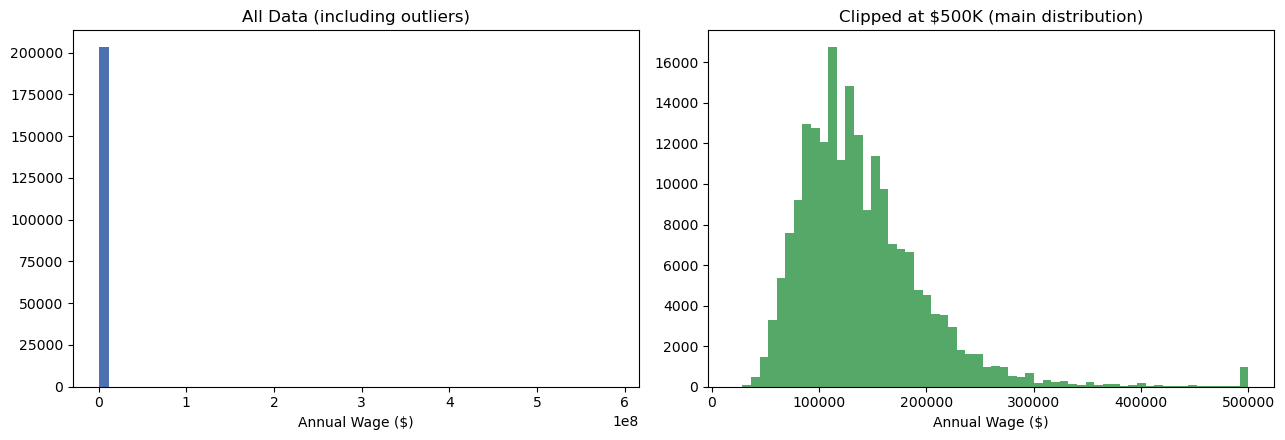

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].hist(df['WAGE_ANNUALIZED'], bins=50, color='#4C72B0')
axes[0].set_title('All Data (including outliers)')
axes[0].set_xlabel('Annual Wage ($)')

axes[1].hist(df['WAGE_ANNUALIZED'].clip(upper=500000), bins=60, color='#55A868') # 500K cap 
axes[1].set_title('Clipped at $500K (main distribution)')
axes[1].set_xlabel('Annual Wage ($)')

plt.tight_layout()
plt.show()

In [28]:
WAGE_CAP = 800_000
n_flagged = (df['WAGE_ANNUALIZED'] > WAGE_CAP).sum()
print(f'{n_flagged} records ({n_flagged/len(df)*100:.2f}%) flagged as implausible wage entries and excluded from wage-related analysis.')

df['WAGE_VALID'] = df['WAGE_ANNUALIZED'] <= WAGE_CAP

475 records (0.23%) flagged as implausible wage entries and excluded from wage-related analysis.


In [29]:
# check for suspicious records that are still present after the cap filter
suspicious_remaining = df[
    (df['WAGE_VALID']) & 
    (df['WAGE_UNIT_OF_PAY'] == 'Hour') & 
    (df['WAGE_RATE_OF_PAY_FROM'] > 200)  # 200/hour = 416,000/year, which is still suspiciously high for an hourly wage
]
print('Suspicious records that are still present after the cap filter:', len(suspicious_remaining))
suspicious_remaining[['WAGE_ANNUALIZED', 'WAGE_UNIT_OF_PAY', 'WAGE_RATE_OF_PAY_FROM']].head(20)

df[df.index.isin(suspicious_remaining.index)][['SOC_TITLE', 'JOB_TITLE', 'WAGE_ANNUALIZED']].head(20)

Suspicious records that are still present after the cap filter: 68


,SOC_TITLE,JOB_TITLE,WAGE_ANNUALIZED
2391,Emergency Medicine Physicians,Physician,473990.4
2651,"Physicians, All Other",Critical Care Physician,520000.0
7094,Hospitalists,Hospitalist Physician,423280.0
12582,"Physicians, All Other",Hospitalist Physician,447200.0
12816,Hospitalists,Intensivist,468000.0
18351,"Mathematical Science Teachers, Postsecondary","Lecturer (Instructor, Data Science Academy)",686400.0
19931,"Physicians, All Other",Critical Care Physician,520000.0
20512,"Physicians, All Other",Intensivist Physician,428480.0
23044,Hospitalists,Intensivist,468000.0
34918,Computer and Information Research Scientists,Research Scientist (Machine Learning & Robotics),499990.4


##### EMPLOYER_NAME cleaning

In [30]:
df['EMPLOYER_NAME'].nunique()

29796

In [31]:
cleaned = df['EMPLOYER_NAME'].str.strip().str.upper()
print('before unique:', df['EMPLOYER_NAME'].nunique())
print('after unique:', cleaned.nunique())

before unique: 29796
after unique: 28948


In [32]:
df['EMPLOYER_NAME'] = cleaned
df['EMPLOYER_NAME'].value_counts().head(30)

EMPLOYER_NAME
AMAZON.COM SERVICES LLC                                      5201
ERNST & YOUNG U.S. LLP                                       4171
APPLE INC.                                                   3965
COGNIZANT TECHNOLOGY SOLUTIONS US CORP                       3441
GOOGLE LLC                                                   2988
MICROSOFT CORPORATION                                        2879
META PLATFORMS, INC                                          2535
INFOSYS LIMITED                                              2444
TATA CONSULTANCY SERVICES LIMITED                            1850
JPMORGAN CHASE & CO.                                         1803
DELOITTE CONSULTING LLP                                      1788
NVIDIA CORPORATION                                           1276
AMAZON WEB SERVICES, INC.                                    1232
COMPUNNEL SOFTWARE GROUP, INC                                1184
TESLA, INC.                                                  1

##### Worksite City/ State name cleaning

In [33]:
for col in ['WORKSITE_CITY', 'WORKSITE_STATE']:
    before = df[col].nunique()
    df[col] = df[col].str.strip().str.upper()
    after = df[col].nunique()
    print(f'{col}: before {before} → after {after}')

WORKSITE_CITY: before 7009 → after 5309
WORKSITE_STATE: before 55 → after 55


In [34]:
sorted(df['WORKSITE_STATE'].unique())

['AK',
 'AL',
 'AR',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC',
 'DE',
 'FL',
 'GA',
 'GU',
 'HI',
 'IA',
 'ID',
 'IL',
 'IN',
 'KS',
 'KY',
 'LA',
 'MA',
 'MD',
 'ME',
 'MI',
 'MN',
 'MO',
 'MP',
 'MS',
 'MT',
 'NC',
 'ND',
 'NE',
 'NH',
 'NJ',
 'NM',
 'NV',
 'NY',
 'OH',
 'OK',
 'OR',
 'PA',
 'PR',
 'RI',
 'SC',
 'SD',
 'TN',
 'TX',
 'UT',
 'VA',
 'VI',
 'VT',
 'WA',
 'WI',
 'WV',
 'WY']

In [35]:
df['WORKSITE_CITY'].value_counts().head(20)

WORKSITE_CITY
NEW YORK         10744
SEATTLE           5501
AUSTIN            5475
SAN JOSE          4991
SAN FRANCISCO     4624
SUNNYVALE         4382
SANTA CLARA       3421
PLANO             3289
ATLANTA           3232
CHICAGO           3225
DALLAS            3100
BELLEVUE          2982
CHARLOTTE         2827
IRVING            2715
HOUSTON           2708
REDMOND           2602
BOSTON            2551
MOUNTAIN VIEW     2330
CUPERTINO         1872
SAN DIEGO         1720
Name: count, dtype: int64

#### Job title cleaning

In [36]:
df['JOB_TITLE'].nunique()

52767

In [37]:
df['SOC_TITLE'].value_counts().head(20)

SOC_TITLE
Software Developers                                66944
Computer Systems Engineers/Architects               7863
Information Technology Project Managers             7519
Software Quality Assurance Analysts and Testers     7253
Data Scientists                                     7223
Computer and Information Systems Managers           5481
Computer Programmers                                4771
Computer Systems Analysts                           4234
Business Intelligence Analysts                      3922
Electronics Engineers, Except Computer              3426
Mechanical Engineers                                3147
Financial and Investment Analysts                   2818
Accountants and Auditors                            2606
Database Administrators                             2579
Electrical Engineers                                2551
Medical Scientists, Except Epidemiologists          2410
Management Analysts                                 2312
Operations Research A

In [38]:
# 1. clean SOC_TITLE values
before = df['SOC_TITLE'].nunique()
df['SOC_TITLE'] = df['SOC_TITLE'].str.strip().str.upper()
after = df['SOC_TITLE'].nunique()
print(f'SOC_TITLE: before {before} → after {after}')

SOC_TITLE: before 595 → after 569


In [39]:
 #2. rerun the wage ranking to see if there are duplicates at the top (e.g., Surgeons with inconsistent capitalization and pluralization)
df[df['WAGE_VALID']].groupby('SOC_TITLE')['WAGE_ANNUALIZED'].median().sort_values(ascending=False).head(20)

SOC_TITLE
UROLOGISTS                                         500000.0
DERMATOLOGISTS                                     450000.0
CARDIOLOGISTS                                      425000.0
ANESTHESIOLOGISTS                                  400000.0
SURGEONS, ALL OTHERS                               400000.0
INTERNISTS, GENERAL                                400000.0
RADIOLOGISTS                                       392533.0
PSYCHIATRIST                                       330240.0
OPHTHALMOLOGISTS, EXCEPT PEDIATRIC                 325000.0
EMERGENCY MEDICINE PHYSICIANS                      320424.0
SURGEONS, ALL OTHER                                320008.0
PHYSICAL MEDICINE AND REHABILITATION PHYSICIANS    313480.0
OBSTETRICIANS AND GYNECOLOGISTS                    307254.5
PHYSICIANS, ALL OTHERS                             305000.0
ORAL AND MAXILLOFACIAL SURGEONS                    300000.0
NEUROLOGISTS                                       299999.2
HOSPITALISTS                  

Note: SOC_TITLE contains some singular/plural variants of the same occupation (e.g., "PSYCHIATRIST" vs "PSYCHIATRISTS") that were not merged. This may cause a small number of occupations to appear twice in rankings with split sample sizes, but does not materially affect overall conclusions.

## 3. Analysis

### 3.1 Top Employers - Who Sponsor the most?

In [40]:
top_employers = df['EMPLOYER_NAME'].value_counts().head(20)
top_employers


EMPLOYER_NAME
AMAZON.COM SERVICES LLC                                      5201
ERNST & YOUNG U.S. LLP                                       4171
APPLE INC.                                                   3965
COGNIZANT TECHNOLOGY SOLUTIONS US CORP                       3441
GOOGLE LLC                                                   2988
MICROSOFT CORPORATION                                        2879
META PLATFORMS, INC                                          2535
INFOSYS LIMITED                                              2444
TATA CONSULTANCY SERVICES LIMITED                            1850
JPMORGAN CHASE & CO.                                         1803
DELOITTE CONSULTING LLP                                      1788
NVIDIA CORPORATION                                           1276
AMAZON WEB SERVICES, INC.                                    1232
COMPUNNEL SOFTWARE GROUP, INC                                1184
TESLA, INC.                                                  1

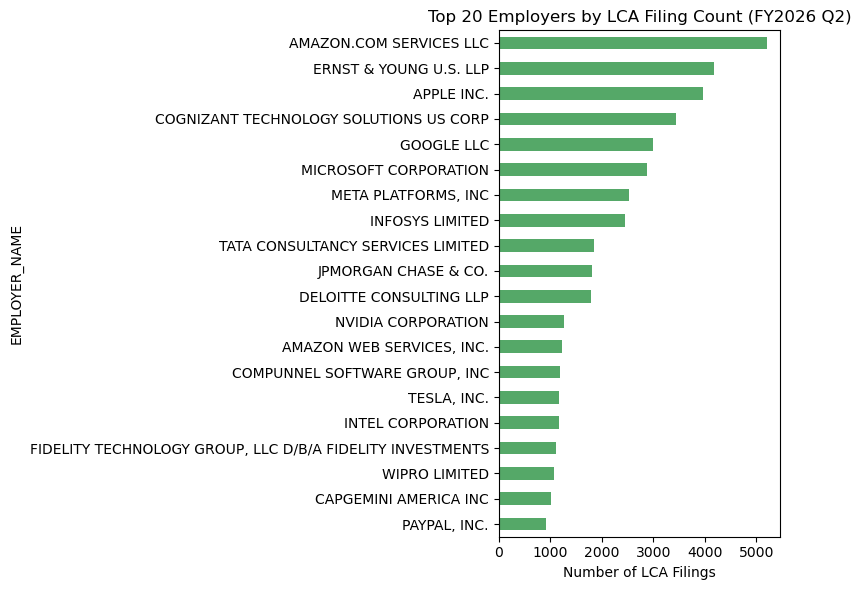

In [41]:
fig, ax = plt.subplots(figsize=(8,6))
top_employers.sort_values().plot.barh(ax=ax, color='#55A868')
ax.set_title('Top 20 Employers by LCA Filing Count (FY2026 Q2)')
ax.set_xlabel('Number of LCA Filings')
plt.tight_layout()
plt.savefig('../outputs/top_employers.png', dpi=120)
plt.show()


In [42]:
#  calculate the share of filings by the top 20 employers
total = len(df)
top20_sum = top_employers.sum()
print(f'Total records: {total}')
print(f'Top 20 employers share: {top20_sum/total*100:.2f}%')

#   count the number of employers with only 1 filing, and those with <= 5 filings
employer_counts = df['EMPLOYER_NAME'].value_counts()
print(f'Employers with only 1 filing: {(employer_counts == 1).sum()}')
print(f'Employers with <= 5 filings: {(employer_counts <= 5).sum()}')
print(f'Total unique employers: {df["EMPLOYER_NAME"].nunique()}')

Total records: 203416
Top 20 employers share: 21.25%
Employers with only 1 filing: 14593
Employers with <= 5 filings: 24387
Total unique employers: 28948


Findings: 
The top 20 employers (just 0.07% of all employers) account for 21.25% of filings — a meaningful concentration effect at the very top.

At the same time, 14,593 employers filed only once, making up 50.4% of the total 28,948 employers — over half of all employers appear in the dataset just a single time.


Employers with 5 or fewer filings number 24,387, or 84.2% of all employers — the vast majority are sponsoring only sporadically, in small numbers.

Practical takeaway: For H-1B job seekers, this suggests that sponsorship opportunities aren't limited to the well-known tech giants.

### 3.2 Top Jobs & Occupations - "most sponsored" and "most highly paid"

In [43]:
print('Top 15 raw JOB_TITLE (noisy, many variants of same role):')
print(df['JOB_TITLE'].value_counts().head(15))
print()
print('Top 15 standardized SOC_TITLE (cleaner grouping):')
print(df['SOC_TITLE'].value_counts().head(15))


Top 15 raw JOB_TITLE (noisy, many variants of same role):
JOB_TITLE
Software Engineer                                       9211
Software Developer                                      5060
Senior Software Engineer                                2807
Assistant Professor                                     2576
Software Engineering                                    1826
Manager JC50 - Computer Systems Engineers/Architects    1264
Data Engineer                                           1252
SOFTWARE DEVELOPER                                      1110
Software Dev Engineer II                                 987
Research Scientist                                       974
Software Development Engineer II                         916
Data Scientist                                           901
SOFTWARE ENGINEER                                        831
Technology Consultant 2                                  776
Staff Software Engineer                                  772
Name: count, dtyp

In [44]:
# check the median annualized wage for each SOC_TITLE, only considering valid wages, and sort them in descending order to see the top 20 highest paying occupations.
df[df['WAGE_VALID']].groupby('SOC_TITLE')['WAGE_ANNUALIZED'].median().sort_values(ascending=False).head(20)

SOC_TITLE
UROLOGISTS                                         500000.0
DERMATOLOGISTS                                     450000.0
CARDIOLOGISTS                                      425000.0
ANESTHESIOLOGISTS                                  400000.0
SURGEONS, ALL OTHERS                               400000.0
INTERNISTS, GENERAL                                400000.0
RADIOLOGISTS                                       392533.0
PSYCHIATRIST                                       330240.0
OPHTHALMOLOGISTS, EXCEPT PEDIATRIC                 325000.0
EMERGENCY MEDICINE PHYSICIANS                      320424.0
SURGEONS, ALL OTHER                                320008.0
PHYSICAL MEDICINE AND REHABILITATION PHYSICIANS    313480.0
OBSTETRICIANS AND GYNECOLOGISTS                    307254.5
PHYSICIANS, ALL OTHERS                             305000.0
ORAL AND MAXILLOFACIAL SURGEONS                    300000.0
NEUROLOGISTS                                       299999.2
HOSPITALISTS                  

Findings: 
By volume, H-1B sponsorship is overwhelmingly concentrated in IT and tech-adjacent occupations.
But by wage, the picture flips entirely. None of the high-volume tech roles appear anywhere near the top of the wage rankings. Instead, the 20 highest-paying occupations are almost exclusively physicians and surgeons.

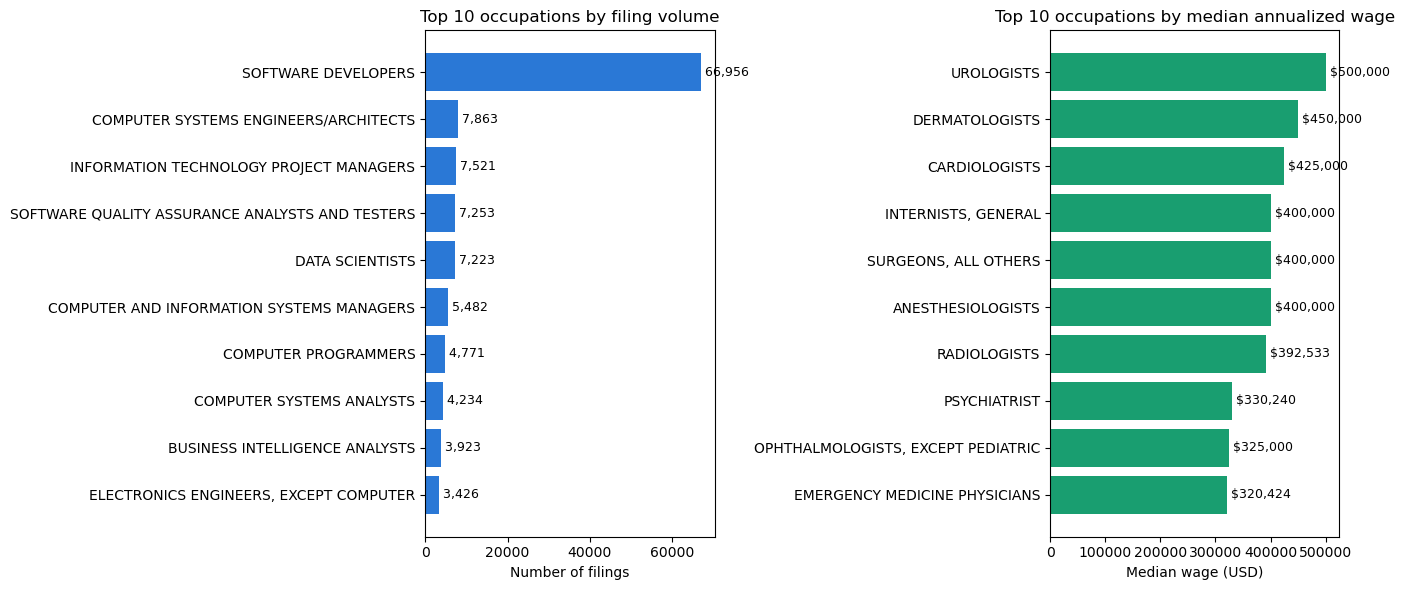

In [45]:
# --- 1. Prepare data (replace with live groupby results if you prefer) ---
vol = df['SOC_TITLE'].value_counts().head(10).sort_values()
wage = (
    df[df['WAGE_VALID']]
    .groupby('SOC_TITLE')['WAGE_ANNUALIZED']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

# --- 2. Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: top occupations by filing volume
axes[0].barh(vol.index, vol.values, color='#2a78d6')
axes[0].set_title('Top 10 occupations by filing volume', fontsize=12)
axes[0].set_xlabel('Number of filings')
axes[0].ticklabel_format(style='plain', axis='x')
for i, v in enumerate(vol.values):
    axes[0].text(v, i, f' {v:,.0f}', va='center', fontsize=9)

# Right: top occupations by median wage
axes[1].barh(wage.index, wage.values, color='#199e70')
axes[1].set_title('Top 10 occupations by median annualized wage', fontsize=12)
axes[1].set_xlabel('Median wage (USD)')
axes[1].ticklabel_format(style='plain', axis='x')
for i, v in enumerate(wage.values):
    axes[1].text(v, i, f' ${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/hyk/Desktop/h1b_project/outputs/h1b_volume_vs_wage.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3  Geographic Analysis - Where are the worksites?

In [46]:
top_states = df['WORKSITE_STATE'].value_counts().head(15)
top_states


WORKSITE_STATE
CA    41299
TX    30721
NY    15575
WA    13112
NJ     9080
NC     8306
IL     8005
GA     7583
MA     7042
FL     6102
PA     5429
MI     5198
VA     4869
OH     4130
AZ     3504
Name: count, dtype: int64

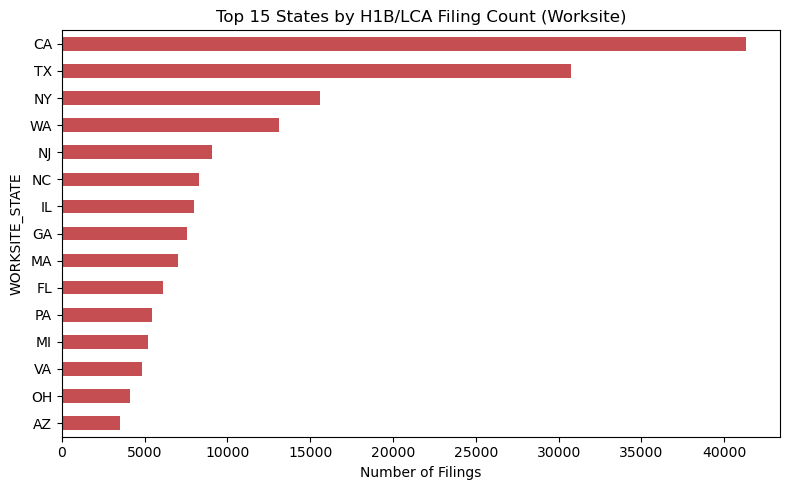

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
top_states.sort_values().plot.barh(ax=ax, color='#C44E52')
ax.set_title('Top 15 States by H1B/LCA Filing Count (Worksite)')
ax.set_xlabel('Number of Filings')
plt.tight_layout()
plt.savefig('Users/hyk/Desktop/h1b_project/outputs/top_states.png', dpi=120)
plt.show()


In [48]:
state_counts = df['WORKSITE_STATE'].value_counts()
state_counts

WORKSITE_STATE
CA    41299
TX    30721
NY    15575
WA    13112
NJ     9080
NC     8306
IL     8005
GA     7583
MA     7042
FL     6102
PA     5429
MI     5198
VA     4869
OH     4130
AZ     3504
MD     2506
TN     2205
CO     2169
MN     2137
IN     2114
CT     2106
MO     2057
WI     1534
OR     1532
UT     1347
SC     1193
AR     1129
DE     1126
IA      869
DC      826
KS      817
KY      816
NE      687
NV      668
LA      643
AL      641
NH      615
RI      550
OK      530
NM      516
MS      308
ID      258
GU      247
WV      220
ND      213
ME      207
SD      142
AK      127
HI      102
VT      102
MT       78
WY       48
PR       38
MP       29
VI        9
Name: count, dtype: int64

In [49]:
import plotly.express as px
from plotly.io import kaleido

state_counts = df['WORKSITE_STATE'].value_counts().reset_index()
state_counts.columns = ['state', 'filings']

fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='filings',
    scope='usa',
    color_continuous_scale='Blues',
    labels={'filings': 'H-1B filings'},
    title='H-1B worksite filings by state'
)

fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()


Findings: H-1B sponsorship is heavily concentrated in California and Texas, followed by a cluster of states with strong tech, finance, or consulting industries (NY, WA, NJ, IL, GA, MA). 

This geographic pattern tracks industry concentration, not political alignment.

## 4. Key Insights & Conclusions

**Data Overview**
- 210,387 LCA filings (H-1B / H-1B1 / E-3) for FY2026 Q2. Note: initial row-count estimate from Excel metadata (~1M) was inflated; the true row count confirmed by direct data read is 210,387.

**Data Quality Findings**
1. **Missing Data:** `WAGE_RATE_OF_PAY_TO` is missing 67% — structural, not an error (single-rate wages don't populate a 'to' field). `DECISION_DATE` missing ~1% — likely pending cases.
2. **Skewness:** Raw wage data had extreme skewness (39.75) traced to a data entry error (annual-scale wages mislabeled with `WAGE_UNIT_OF_PAY = 'Hour'`, causing the annualization logic to multiply an already-annual figure by 2,080). After flagging and excluding ~0.23% of implausible records (`WAGE_ANNUALIZED` > $800K), skewness dropped to 2.14 — a realistic right-skewed distribution typical of salary data. Records were flagged via a `WAGE_VALID` boolean rather than dropped, preserving their non-wage fields for other analyses.
3. **Categorical text noise:** `EMPLOYER_NAME`, `WORKSITE_CITY`, and `SOC_TITLE` all had inconsistent casing/whitespace that inflated unique counts (e.g. `WORKSITE_CITY` dropped from 7,009 to 5,309 unique values after standardization). `SOC_TITLE` additionally had ~25 singular/plural variants of the same occupation (e.g. `PSYCHIATRIST` vs `PSYCHIATRISTS`) that were identified but left unmerged — a known limitation noted for any occupation-level rollup. `JOB_TITLE` (free-text, 52,767 unique values) was excluded from grouping entirely in favor of the standardized `SOC_TITLE` field. `WORKSITE_STATE` was checked and confirmed clean (55 valid US state/territory codes).

**Business Insights**
- **Top sponsors:** Amazon, EY, Apple, Cognizant, Google, Microsoft, Meta, Infosys dominate filing volume — a mix of Big Tech and IT consulting/staffing firms. However, sponsorship is highly dispersed overall: the top 20 employers account for only 21.25% of filings, while over half of all 28,948 unique employers filed just once — suggesting H-1B opportunities extend well beyond the well-known large sponsors.
- **Top occupations by volume:** Software Developers dominate (66,956 filings, more than the next several occupations combined), followed by Computer Systems Engineers/Architects, IT Project Managers, and Data Scientists — tech roles account for nearly all of the top 15 by filing count.
- **Volume and pay diverge sharply:** None of the highest-volume tech occupations rank among the highest-paid. The top 20 occupations by median wage are almost entirely physician specialties (Urologists ~$500K, Dermatologists ~$450K, Cardiologists ~$425K), reflecting the licensure-intensive, specialized nature of medicine rather than IT's broader but lower-median demand. Overall median wage across all filings is ~$130K.
- **Geography:** CA and TX are the top two states by filing volume (CA leads with 41,299 filings, TX follows with 30,721), well ahead of NY, WA, and NJ. The concentration pattern tracks industry hubs — tech, finance, and consulting — rather than political alignment: the top states span both traditionally blue (CA, NY, WA, IL, MA) and red (TX, GA, NC) states alike.
- **Employer approval behavior:** Most major sponsors show >95% Certified rates; some (e.g. Apple) show a notably higher 'Certified - Withdrawn' share, worth investigating further (could reflect internal role changes/cancellations after approval).

**Caveats for future phases**
- This is one quarter of data (FY2026 Q2) — seasonal/time trends can't be reliably assessed yet. Adding Q1 and prior-year data would strengthen trend analysis.
- LCA certification ≠ actual H-1B visa approval (USCIS lottery/petition stage is a separate, unobserved bottleneck not captured in this dataset).
- `SOC_TITLE` singular/plural duplicates and employer parent-company groupings (e.g. Amazon's multiple legal entities) were identified but not fully resolved; occupation- and employer-level counts may be slightly undercounted as a result.